In [2]:
# 03_spending_hierarchical.ipynb

# 1. DATA LOADING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the preprocessed dataset
df = pd.read_csv("preprocessed_customer_data.csv")

In [3]:
# 2. FEATURE SELECTION (Spending Behavior)

spending_features = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]
X = df[spending_features]

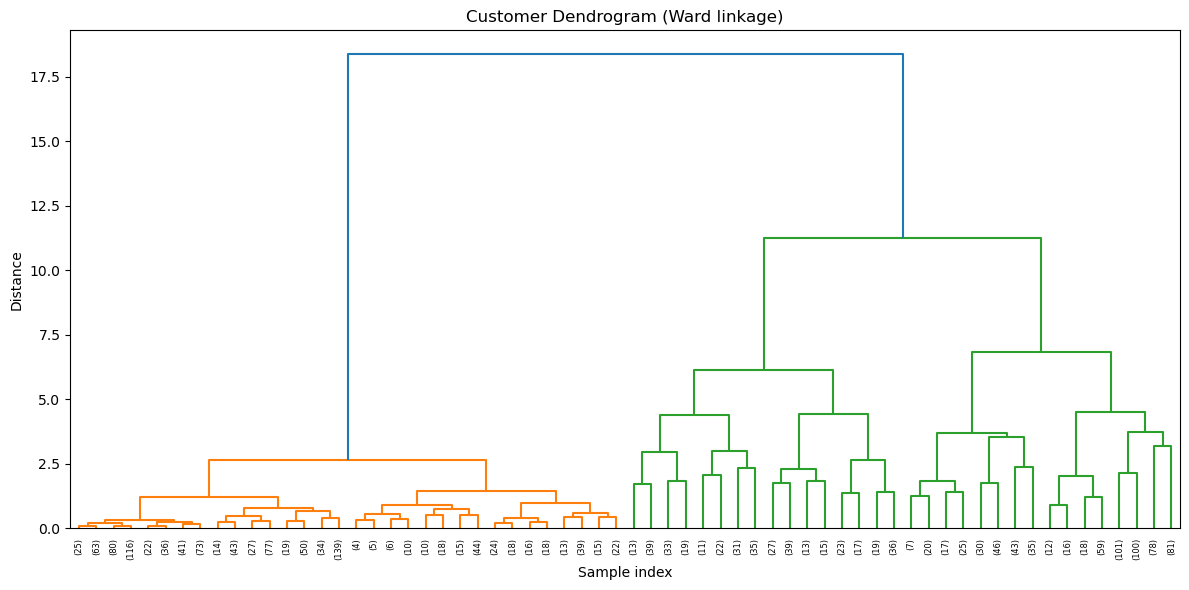

In [4]:
# 3. AGNES HIERARCHICAL CLUSTERING: DENDROGRAM

# Generate linkage matrix for dendrogram
linkage_matrix = linkage(X, method='ward')  # Ward minimizes variance within clusters

# Plot dendrogram to help choose number of clusters
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Dendrogram using Ward linkage")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [19]:
# 4. APPLY AGGLOMERATIVE CLUSTERING

# Based on dendrogram, select appropriate number of clusters
optimal_k = 2  # Change this if dendrogram suggests differently

agg_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['SpendingCluster_H'] = agg_model.fit_predict(X)

# Evaluate clustering quality using Silhouette Score
sil_score = silhouette_score(X, df['SpendingCluster_H'])
print(f"🧮 Silhouette Score for Agglomerative Clustering: {sil_score:.4f}")

🧮 Silhouette Score for Agglomerative Clustering: 0.4226


📊 Average Spending per Cluster:


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
SpendingCluster_H,,,,,,
0,0.376056,0.243118,0.179875,0.268704,0.189532,0.230645
1,0.041104,0.027222,0.017838,0.028016,0.021053,0.047900


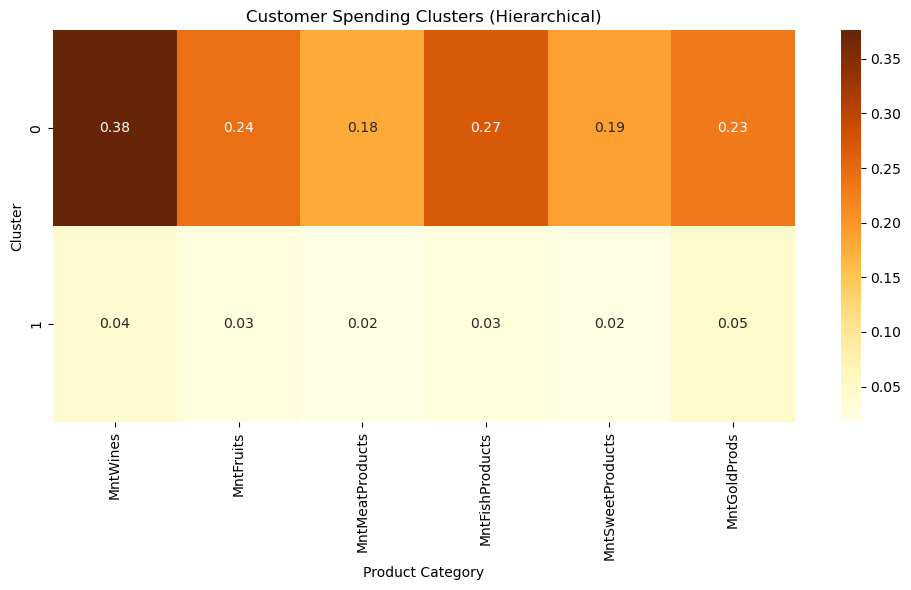

In [21]:
# 5. CLUSTER PROFILE ANALYSIS

# Average spending per cluster
cluster_profile = df.groupby('SpendingCluster_H')[spending_features].mean()

print("📊 Average Spending per Cluster:")
display(cluster_profile)

# Plot heatmap of cluster spending profile
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Customer Spending Clusters (Hierarchical)")
plt.ylabel("Cluster")
plt.xlabel("Product Category")
plt.tight_layout()
plt.show()

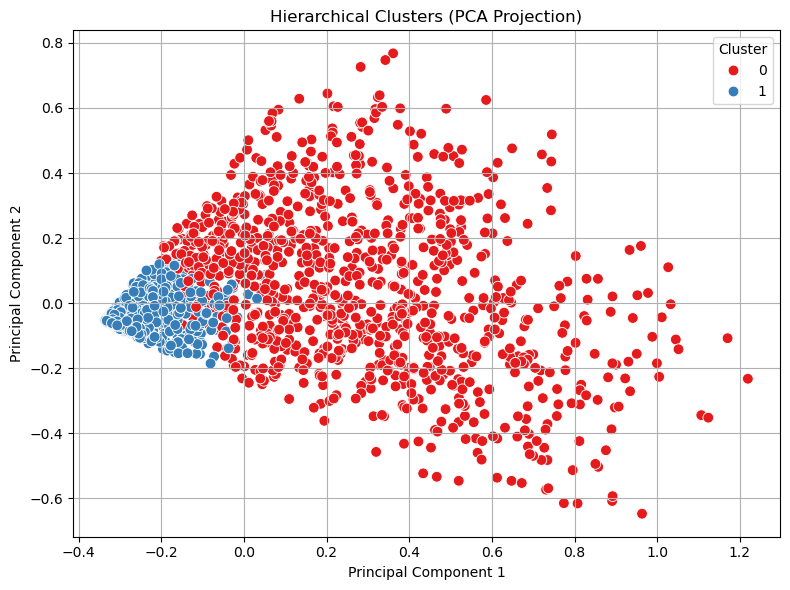

In [23]:
# 6. VISUALIZE CLUSTERS USING PCA (2D)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['SpendingCluster_H']

# Plot 2D PCA projection
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=60)
plt.title("Hierarchical Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()